# Benchmarks

Data Source: https://github.com/blof/LINERLIB

In [1]:
import pandas as pd

from pprint import pprint
import cma
import test_benchmarks_utils as benchutils
from test_benchmarks_utils import \
	read_vessel_class_data, \
	read_port_data, \
	read_demand

In [2]:
pacific = [
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore',
	'Brunei', 'Timor-Leste',
	'China', 'Japan', 'South Korea', 'North Korea',
	'Canada', 'Mexico',
	'Fiji', 'Australia'
]
_, cma_portpool = cma.read_port_data()

In [3]:
vessel_pool = read_vessel_class_data()
portpool = read_port_data(vessel_pool, cma_portpool)
display(vessel_pool.numbers_list)
display(vessel_pool)

[np.int64(12), np.int64(24), np.int64(22), np.int64(42), 0, 0]

     Vessel Type  Vessel Number
0  Rank 1 Vessel             12
1  Rank 2 Vessel             24
2  Rank 3 Vessel             22
3  Rank 4 Vessel             42
4  Rank 5 Vessel              0
5  Rank 6 Vessel              0

435

In Total  127  ports are plotted


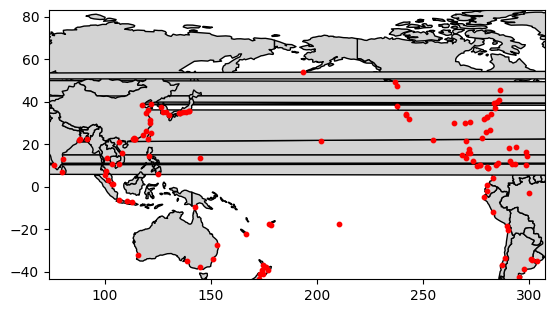

In [4]:
display(portpool.get_number_of_ports())
_, _, portpool_Pacific = portpool.plot(pacific, center_pacific=True)

In [5]:
# create a new pool of ports with richer information
week_demands, unit_revenue = read_demand(portpool_Pacific)
dist_mat = cma.read_sailing_distance_data(portpool_Pacific)

portgraph = cma.PortGraph(portpool_Pacific, dist_mat, week_demands, unit_revenue)
num_ports = portgraph.get_number_of_ports()
print(f'In total {num_ports} ports have freight demand')
len(portgraph.filtered_by_transship_capacity())

In total 45 ports have freight demand


45

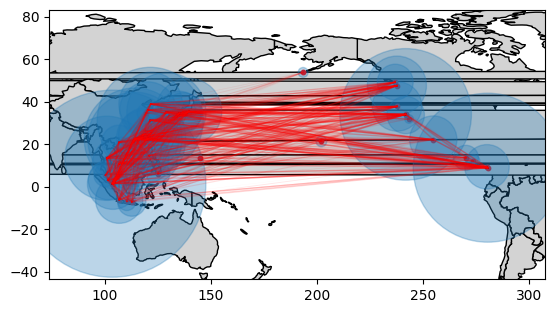

In [6]:
# plot the demands between ports
_, ax, _ = portgraph.plot(pacific, center_pacific=True)

In [7]:
from cma import ServiceGraph, create_service_line

line_1 = create_service_line('line 1', benchutils.line_1_idlst, portpool)
line_2 = create_service_line('line 2', benchutils.line_2_idlst, portpool)
line_3 = create_service_line('line 3', benchutils.line_3_idlst, portpool)
line_4 = create_service_line('line 4', benchutils.line_4_idlst, portpool)
line_5 = create_service_line('line 5', benchutils.line_5_idlst, portpool)
line_6 = create_service_line('line 6', benchutils.line_6_idlst, portpool)
line_7 = create_service_line('line 7', benchutils.line_7_idlst, portpool)
line_8 = create_service_line('line 8', benchutils.line_8_idlst, portpool)
line_9 = create_service_line('line 9', benchutils.line_9_idlst, portpool)
line_10 = create_service_line('line 10', benchutils.line_10_idlst, portpool)
line_11 = create_service_line('line 11', benchutils.line_11_idlst, portpool)
line_12 = create_service_line('line 12', benchutils.line_12_idlst, portpool)
line_13 = create_service_line('line 13', benchutils.line_13_idlst, portpool)
line_14 = create_service_line('line 14', benchutils.line_14_idlst, portpool)
line_15 = create_service_line('line 15', benchutils.line_15_idlst, portpool)
line_16 = create_service_line('line 16', benchutils.line_16_idlst, portpool)
line_17 = create_service_line('line 17', benchutils.line_17_idlst, portpool)

init_service_lines = [line_1, line_2, line_3, line_4, line_5, line_6, line_7, line_8, line_9,
	line_10, line_11, line_12, line_13, line_14, line_15, line_16, line_17]
init_service_graph = ServiceGraph(init_service_lines)

In [8]:
# create a week prediction model
week_predictor = cma.create_week_predictor()
week_predictor.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:               OLS              Adj. R-squared:     0.890   
Dependent Variable:  weeks            AIC:                92.3843 
Date:                2025-08-15 12:28 BIC:                103.7352
No. Observations:    49               Log-Likelihood:     -40.192 
Df Model:            5                F-statistic:        78.32   
Df Residuals:        43               Prob (F-statistic): 1.77e-20
R-squared:           0.901            Scale:              0.34412 
------------------------------------------------------------------
                     Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
------------------------------------------------------------------
const               -0.5318   0.4189 -1.2695 0.2111 -1.3767 0.3130
sailing_distance     0.0005   0.0000 13.8420 0.0000  0.0004 0.0005
stops_number         0.0549   0.0379  1.4485 0.1547 -0.0215 0.1313
ave_productivity     0.0009   0.0022  0.4213 0.6757 -0.0035 0.0053
ave_demand_inflows   0.0002   0.0001  1.7211 0.0924 -0.0000 0.0005
ave_demand_outflows  0.0001   0.0002  0.5632 0.5763 -0.0003 0.0006
------------------------------------------------------------------
Omnibus:               8.717        Durbin-Watson:           1.521
Prob(Omnibus):         0.013        Jarque-Bera (JB):        7.882
Skew:                  0.909        Prob(JB):                0.019
Kurtosis:              3.743        Condition No.:           33496
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

In [9]:
# solve the optimal demand fulfillment
sol = init_service_graph.solve_approximated(portgraph, vessel_pool, week_predictor, min_cost=False)
init_service_graph.total_profit()

/Users/linsheng/Documents/GitHub/nus_cma_project/.venv/lib/python3.13/site-packages/cvxpy/problems/problem.py:167: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


np.float64(388048.2222222211)

In [10]:
line_weeks = sol['weeks']
ship_vars = sol['ships']
line_capacities = sol['capacities']

print('Line Name', ' \t', 'distance', '\t', 'week', '\t', 'ships', '\t\t\t', 'capacities')
for line, week, line_ships, line_cap in zip(init_service_lines, line_weeks, ship_vars, line_capacities):
	line_ships_val = [int(ship.value) for ship in line_ships]
	print(
		line.name(), ' \t',
		int(line.get_distance(portgraph)), '\t\t',
		week, '\t',
		line_ships_val, '\t',
		line_cap.value)
print('>>> revenue            =', sol['revenue'].value)
print('>>> penalty            =', sol['penalty'].value)
print('>>> portcall cost      =', sol['portcall cost'].value)
print('>>> bunkering cost     =', sol['bunkering cost'].value)
print('>>> transshipment cost =', sol['transshipment cost'].value)
print('>>> chartering cost    =', sol['chartering cost'].value)

# benchmark weeks:
# [7, 13, 9, 3, 13, 7, 8, 4, 2, 2, 4, 10, 1.5, 5, 4, 6, 1]

Line Name  	 distance 	 week 	 ships 			 capacities
line 1  	 9688 		 6.0 	 [0, 1, 0, 2, 0, 0] 	 5600.0
line 2  	 30411 		 14.0 	 [0, 1, 1, 6, 0, 0] 	 16400.0
line 3  	 21903 		 11.0 	 [4, 18, 15, 0, 0, 0] 	 34200.0
line 4  	 5723 		 4.0 	 [0, 0, 2, 2, 0, 0] 	 7200.0
line 5  	 30581 		 15.0 	 [0, 0, 0, 13, 0, 0] 	 31200.0
line 6  	 13466 		 7.0 	 [0, 0, 1, 4, 0, 0] 	 10800.0
line 7  	 16129 		 9.0 	 [1, 0, 0, 4, 0, 0] 	 10050.0
line 8  	 5708 		 4.0 	 [1, 0, 1, 0, 0, 0] 	 1650.0
line 9  	 3395 		 3.0 	 [1, 1, 0, 0, 0, 0] 	 1250.0
line 10  	 4034 		 3.0 	 [0, 1, 1, 3, 0, 0] 	 9200.0
line 11  	 13594 		 7.0 	 [2, 2, 0, 0, 0, 0] 	 2500.0
line 12  	 18840 		 9.0 	 [1, 0, 0, 2, 0, 0] 	 5250.0
line 13  	 2581 		 1.0 	 [1, 0, 0, 0, 0, 0] 	 450.0
line 14  	 9103 		 5.0 	 [0, 0, 0, 4, 0, 0] 	 9600.0
line 15  	 8945 		 5.0 	 [0, 0, 0, 1, 0, 0] 	 2400.0
line 16  	 9740 		 6.0 	 [0, 0, 1, 1, 0, 0] 	 3600.0
line 17  	 992 		 0.5 	 [1, 0, 0, 0, 0, 0] 	 450.0
>>> revenue            = 41574751.9480519

In [11]:
demand_routes = sol['demand routes']
trans_ports = portgraph.filtered_by_transship_capacity()
print(len(trans_ports))
od_pairs_dict = init_service_graph.get_all_paths(portgraph, trans_ports)
od_pairs = od_pairs_dict['od_pairs']
od_pairs_paths = od_pairs_dict['od_pairs_path']
od_pairs_demand = od_pairs_dict['od_pairs_demand']
total_demand_rev = 0
realized_rev = 0

for x_od, od in zip(demand_routes, od_pairs):
	unit_rev = portgraph.get_unit_revenue_by_idx(*od)
	od_demand = portgraph.get_demand_by_idx(*od)
	accepted_demand = 0
	for x_od_p in x_od:
		accepted_demand += x_od_p.value
	total_demand_rev += od_demand * unit_rev
	realized_rev += accepted_demand * unit_rev
	print('from', od[0], 'to', od[1],
		' demand =', od_demand,
		' unit_prize = ', unit_rev,
		' fulfilled =', accepted_demand)

print('total demand revenue =', total_demand_rev)
print('realized revenue =', realized_rev, '(', 100 * realized_rev / total_demand_rev, '%)')

45
from 43 to 39  demand = 320.0  unit_prize =  1390.0  fulfilled = 320.0
from 43 to 12  demand = 715.0  unit_prize =  800.0  fulfilled = 715.0
from 37 to 12  demand = 346.0  unit_prize =  410.0  fulfilled = 346.0
from 32 to 12  demand = 403.0  unit_prize =  810.0  fulfilled = 403.00000000000006
from 27 to 12  demand = 1066.0  unit_prize =  550.0  fulfilled = 1066.0
from 15 to 12  demand = 866.0  unit_prize =  410.0  fulfilled = 866.0
from 37 to 25  demand = 250.0  unit_prize =  1580.0  fulfilled = 250.0
from 27 to 25  demand = 673.0  unit_prize =  1590.0  fulfilled = 673.0
from 13 to 12  demand = 1739.0  unit_prize =  530.0  fulfilled = 1739.0
from 13 to 10  demand = 857.0  unit_prize =  1660.0  fulfilled = 857.0
from 32 to 10  demand = 283.0  unit_prize =  1450.0  fulfilled = 283.0
from 27 to 10  demand = 444.0  unit_prize =  1670.0  fulfilled = 444.0
from 43 to 10  demand = 223.0  unit_prize =  1380.0  fulfilled = 170.42424242424295
from 13 to 25  demand = 823.0  unit_prize =  1610.

## MCTS

In [12]:
tree = cma.MonteCarloTree(servicegraph=init_service_graph,
	portgraph=portgraph, vesselpool=vessel_pool,
	discount_fac=0.5,  # control the simulation deepth
	c_param=0.5,       # balance exploration and exploitation
	max_depth=20,      # how many steps of adjustments are allowed
	week_predict_model=week_predictor)

In [13]:
import time
from IPython.display import clear_output

run_time_seconds = 30 * 60   # 30 minutes
start_time = time.time()

while True:
	if time.time() - start_time >= run_time_seconds:
		print('Run time finished')
		break
	tree.run(10, True)
	clear_output(wait=False)
	print(tree.recorder())
	print('-----------------')
	tree.display_best_node(portgraph)

{'num_expand': 27, 'num_rollout': 23}
-----------------
Best Action Trace:
Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x161c33c50> expand
Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x161c33c50> expand


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1059d5a90>>
Traceback (most recent call last):
  File "/Users/linsheng/Documents/GitHub/nus_cma_project/.venv/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x31cf5fc80> rollout
Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x31cf5e3c0> expand
Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x31cf5e3c0> expand
Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x31cf5dc70> rollout
Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x31cf5d010> expand
Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x31cf5f2f0> rollout
Select: <cma.mcts.MonteCarloTreeSearchNode object at 0x31cf5fbf0> expand


: 

: 